# EDA — stationnement-voie-publique-emplacements.csv
Urban Data Explorer · opendata.paris.fr

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

## 1. Chargement

In [2]:
FILE = 'brute/indicateur-Score-accessibilité-mobilité/stationnement-voie-publique-emplacements.csv'

# Fichier volumineux (~300k lignes) — on charge avec low_memory=False
df = pd.read_csv(FILE, sep=';', low_memory=False)

# Nettoyage BOM UTF-8
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)

print(f'Shape : {df.shape}')
print(f'Colonnes : {list(df.columns)}')
df.head()

Shape : (65632, 43)
Colonnes : ['Régime prioritaire', 'Régime particulier', 'Type de stationnement', 'Arrondissement', 'Nombre places calculées', 'Nombre places réelles', 'Zones Résidentielles', 'Localisation stationnement', 'Numéro voie', 'Type voie', 'Nom voie', 'Complément numéro voie', 'Localisation numéro', 'Parité', 'Longueur', 'Largeur', 'Surface calculée', 'Signalisation horizontale', 'Signalisation verticale', 'Conformité signalisation', 'Type mobilier', 'Numéro mobilier', 'Plage horaire 1-Début', 'Plage horaire 1-Fin', 'Plage horaire 2-Début', 'Plage horaire 2-Fin', 'Plage horaire 3-Début', 'Plage horaire 3-Fin', 'Nouvel identifiant', 'Ancien identifiant', 'Code voie Ville de Paris', 'Numéro séquentiel Tronçon voie', 'Numéro ilot', 'Numéro IRIS', 'Zone ASP', 'Numéro Section Territoriale de Voirie', 'Compétence préfecture', 'Dernière modification', 'Date du relevé', '1er numéro tronçon voie', 'Dernier numéro tronçon voie', 'geo_shape', 'geo_point_2d']


,Régime prioritaire,Régime particulier,Type de stationnement,Arrondissement,Nombre places calculées,Nombre places réelles,Zones Résidentielles,Localisation stationnement,Numéro voie,Type voie,...,Numéro IRIS,Zone ASP,Numéro Section Territoriale de Voirie,Compétence préfecture,Dernière modification,Date du relevé,1er numéro tronçon voie,Dernier numéro tronçon voie,geo_shape,geo_point_2d
0,PAYANT MIXTE,Mixte,Longitudinal,13,1,1,13H,Chaussée,NaN,RUE,...,NaN,13Z1,STV Sud-Est,NaN,2020-07-24,2020-07-09,2.0,22,"{""coordinates"": [2.3471517468142933, 48.836073...","48.83607364266024, 2.3471517468142933"
1,PAYANT MIXTE,Mixte,Longitudinal,7,5,5,7G,Contre allée,NaN,AV,...,NaN,07Z1,STV Sud,NaN,2024-07-31,2020-09-01,13.0,17,"{""coordinates"": [2.3012430823303265, 48.860515...","48.860515504511746, 2.3012430823303265"
2,2 ROUES,Vélos,Bataille,15,6,6,15K,Trottoir,56.0,RUE,...,NaN,15Z4,STV Sud-Ouest,NaN,2023-12-18,2023-08-09,75.0,85,"{""coordinates"": [2.300110890225367, 48.8433874...","48.84338747444542, 2.300110890225367"
3,LIVRAISON,ZL périodique,Longitudinal,17,1,1,17R,Chaussée,96.0,RUE,...,NaN,17ZJ,STV Nord-Ouest,NaN,2019-01-04,2020-08-31,95.0,99,"{""coordinates"": [2.3191986564789278, 48.889152...","48.889152448099374, 2.3191986564789278"
4,PAYANT MIXTE,Mixte,Longitudinal,18,2,2,18N,Chaussée,NaN,RUE DES,...,NaN,18Z5,STV Nord-Ouest,NaN,2019-01-04,2020-08-31,2.0,12,"{""coordinates"": [2.3376047069800383, 48.890875...","48.89087592189656, 2.3376047069800383"


## 2. Infos générales

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65632 entries, 0 to 65631
Data columns (total 43 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   Régime prioritaire                     65632 non-null  object 
 1   Régime particulier                     65632 non-null  object 
 2   Type de stationnement                  65632 non-null  object 
 3   Arrondissement                         65632 non-null  int64  
 4   Nombre places calculées                65632 non-null  int64  
 5   Nombre places réelles                  65632 non-null  int64  
 6   Zones Résidentielles                   65632 non-null  object 
 7   Localisation stationnement             65632 non-null  object 
 8   Numéro voie                            42366 non-null  float64
 9   Type voie                              65632 non-null  object 
 10  Nom voie                               65632 non-null  object 
 11  Co

In [4]:
df.describe(include='all')

,Régime prioritaire,Régime particulier,Type de stationnement,Arrondissement,Nombre places calculées,Nombre places réelles,Zones Résidentielles,Localisation stationnement,Numéro voie,Type voie,...,Numéro IRIS,Zone ASP,Numéro Section Territoriale de Voirie,Compétence préfecture,Dernière modification,Date du relevé,1er numéro tronçon voie,Dernier numéro tronçon voie,geo_shape,geo_point_2d
count,65632,65632,65632,65632.000000,65632.000000,65632.000000,65632,65632,42366.000000,65632,...,1.0,65632,65632,0.0,65632,65632,65629.000000,65632.00000,65632,65632
unique,10,51,3,NaN,NaN,NaN,162,10,NaN,107,...,NaN,106,6,NaN,1306,1273,NaN,NaN,65632,65632
top,PAYANT MIXTE,Mixte,Longitudinal,NaN,NaN,NaN,2E,Chaussée,NaN,RUE,...,NaN,16Z5,STV Nord-Ouest,NaN,2019-01-04,2020-08-31,NaN,NaN,"{""coordinates"": [2.3132356063954345, 48.849900...","48.84990067096174, 2.3132356063954345"
freq,21778,21734,42350,NaN,NaN,NaN,1024,49780,NaN,28312,...,NaN,1342,13010,NaN,14012,16469,NaN,NaN,1,1
mean,NaN,NaN,NaN,12.921989,5.571611,5.583389,NaN,NaN,42.951919,NaN,...,751166177.0,NaN,NaN,NaN,NaN,NaN,33.378826,43.76222,NaN,NaN
std,NaN,NaN,NaN,4.983416,6.712108,6.809991,NaN,NaN,52.698934,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,49.267824,50.62169,NaN,NaN
min,NaN,NaN,NaN,1.000000,0.000000,0.000000,NaN,NaN,0.000000,NaN,...,751166177.0,NaN,NaN,NaN,NaN,NaN,0.000000,0.00000,NaN,NaN
25%,NaN,NaN,NaN,9.000000,1.000000,1.000000,NaN,NaN,9.000000,NaN,...,751166177.0,NaN,NaN,NaN,NaN,NaN,2.000000,11.00000,NaN,NaN
50%,NaN,NaN,NaN,14.000000,4.000000,4.000000,NaN,NaN,23.000000,NaN,...,751166177.0,NaN,NaN,NaN,NaN,NaN,12.000000,25.00000,NaN,NaN
75%,NaN,NaN,NaN,17.000000,8.000000,8.000000,NaN,NaN,57.000000,NaN,...,751166177.0,NaN,NaN,NaN,NaN,NaN,46.000000,57.00000,NaN,NaN


## 3. Valeurs manquantes

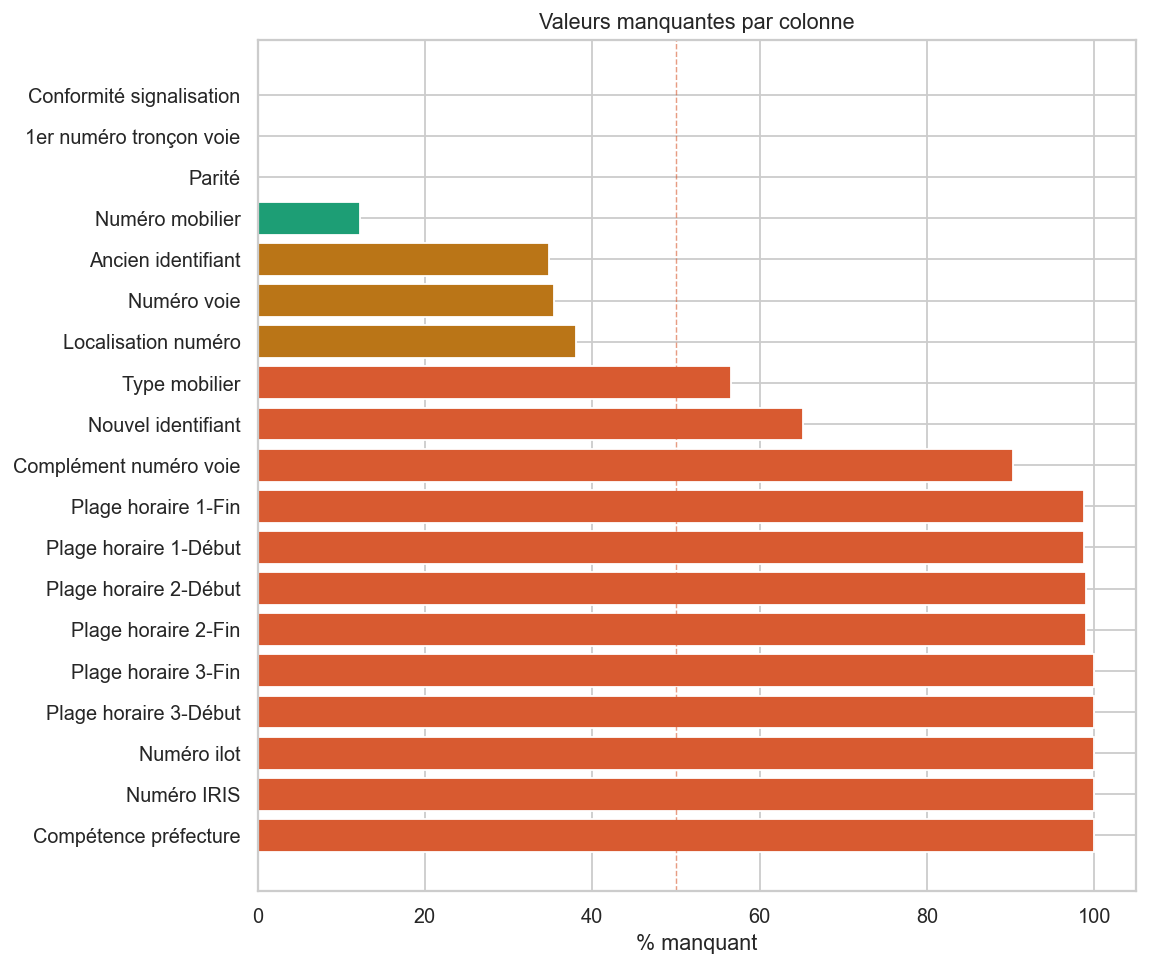

,% manquant
Compétence préfecture,100.000000
Numéro IRIS,99.998476
Numéro ilot,99.998476
Plage horaire 3-Début,99.919247
Plage horaire 3-Fin,99.919247
Plage horaire 2-Fin,99.050768
Plage horaire 2-Début,99.049244
Plage horaire 1-Début,98.813079
Plage horaire 1-Fin,98.813079
Complément numéro voie,90.301987


In [5]:
missing = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_nonzero = missing[missing > 0]

if missing_nonzero.empty:
    print('✅ Aucune valeur manquante')
else:
    fig, ax = plt.subplots(figsize=(9, max(3, len(missing_nonzero) * 0.4)))
    colors = ['#D85A30' if v > 50 else '#BA7517' if v > 20 else '#1D9E75' for v in missing_nonzero.values]
    ax.barh(missing_nonzero.index, missing_nonzero.values, color=colors)
    ax.set_xlabel('% manquant')
    ax.set_title('Valeurs manquantes par colonne')
    ax.axvline(50, color='#D85A30', linestyle='--', linewidth=0.8, alpha=0.6)
    plt.tight_layout()
    plt.show()

display(missing_nonzero.rename('% manquant').to_frame())

## 4. Doublons

In [6]:
n_dup = df.duplicated().sum()
print(f'Doublons : {n_dup} ({n_dup/len(df)*100:.2f}%)')

Doublons : 0 (0.00%)


## 5. Détection colonnes clés

In [7]:
def find_col(df, *keywords):
    for kw in keywords:
        match = [c for c in df.columns if kw.lower() in c.lower()]
        if match: return match[0]
    return None

col_map = {
    'arrondissement' : find_col(df, 'arrond', 'arrondissement'),
    'type_stat'      : find_col(df, 'typsta', 'type_sta', 'typestat'),
    'regime_prio'    : find_col(df, 'regpri', 'regime_p', 'priorite'),
    'regime_par'     : find_col(df, 'regpar', 'regime_par', 'parking'),
    'nb_places'      : find_col(df, 'nombre', 'nb_place', 'places', 'empl'),
    'geo_point'      : find_col(df, 'geo_point', 'geopoint', 'geo_shape'),
    'mobilite'       : find_col(df, 'typemob', 'mobilite', 'pmr', 'handicap'),
    'localisation'   : find_col(df, 'locsta', 'localisa'),
}

print('Colonnes détectées :')
for k, v in col_map.items():
    status = '✅' if v else '❌'
    print(f'  {status}  {k:20s} → {v}')

print(f'\nToutes les colonnes : {list(df.columns)}')

Colonnes détectées :
  ✅  arrondissement       → Arrondissement
  ❌  type_stat            → None
  ❌  regime_prio          → None
  ❌  regime_par           → None
  ✅  nb_places            → Nombre places calculées
  ✅  geo_point            → geo_point_2d
  ❌  mobilite             → None
  ✅  localisation         → Localisation stationnement

Toutes les colonnes : ['Régime prioritaire', 'Régime particulier', 'Type de stationnement', 'Arrondissement', 'Nombre places calculées', 'Nombre places réelles', 'Zones Résidentielles', 'Localisation stationnement', 'Numéro voie', 'Type voie', 'Nom voie', 'Complément numéro voie', 'Localisation numéro', 'Parité', 'Longueur', 'Largeur', 'Surface calculée', 'Signalisation horizontale', 'Signalisation verticale', 'Conformité signalisation', 'Type mobilier', 'Numéro mobilier', 'Plage horaire 1-Début', 'Plage horaire 1-Fin', 'Plage horaire 2-Début', 'Plage horaire 2-Fin', 'Plage horaire 3-Début', 'Plage horaire 3-Fin', 'Nouvel identifiant', 'Ancien ide

## 6. Répartition par type de stationnement

In [8]:
type_col = col_map['type_stat']

if type_col:
    vc = df[type_col].value_counts()
    print(f'Types distincts : {len(vc)}')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    colors = ['#378ADD','#1D9E75','#D85A30','#BA7517','#888780',
              '#534AB7','#D4537E','#0F6E56','#993C1D','#3B6D11']

    ax1.barh(vc.index.astype(str), vc.values, color=colors[:len(vc)])
    ax1.set_title('Nb emplacements par type')
    ax1.set_xlabel('Nombre')
    ax1.invert_yaxis()

    # Top 6 pour le pie
    vc_pie = vc.head(6)
    other = vc[6:].sum()
    if other > 0:
        vc_pie = pd.concat([vc_pie, pd.Series({'Autres': other})])
    ax2.pie(vc_pie.values, labels=vc_pie.index.astype(str),
            autopct='%1.1f%%', colors=colors[:len(vc_pie)], startangle=140)
    ax2.set_title('Répartition par type (%)')

    plt.suptitle(f'Distribution par type de stationnement ({type_col})', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()
    display(vc.rename('nb_emplacements').to_frame())
else:
    print('❌ Colonne type stationnement non trouvée')

❌ Colonne type stationnement non trouvée


## 7. Répartition par arrondissement

Complétude : 65632/65632 (100.0%)
Valeurs uniques : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22)]


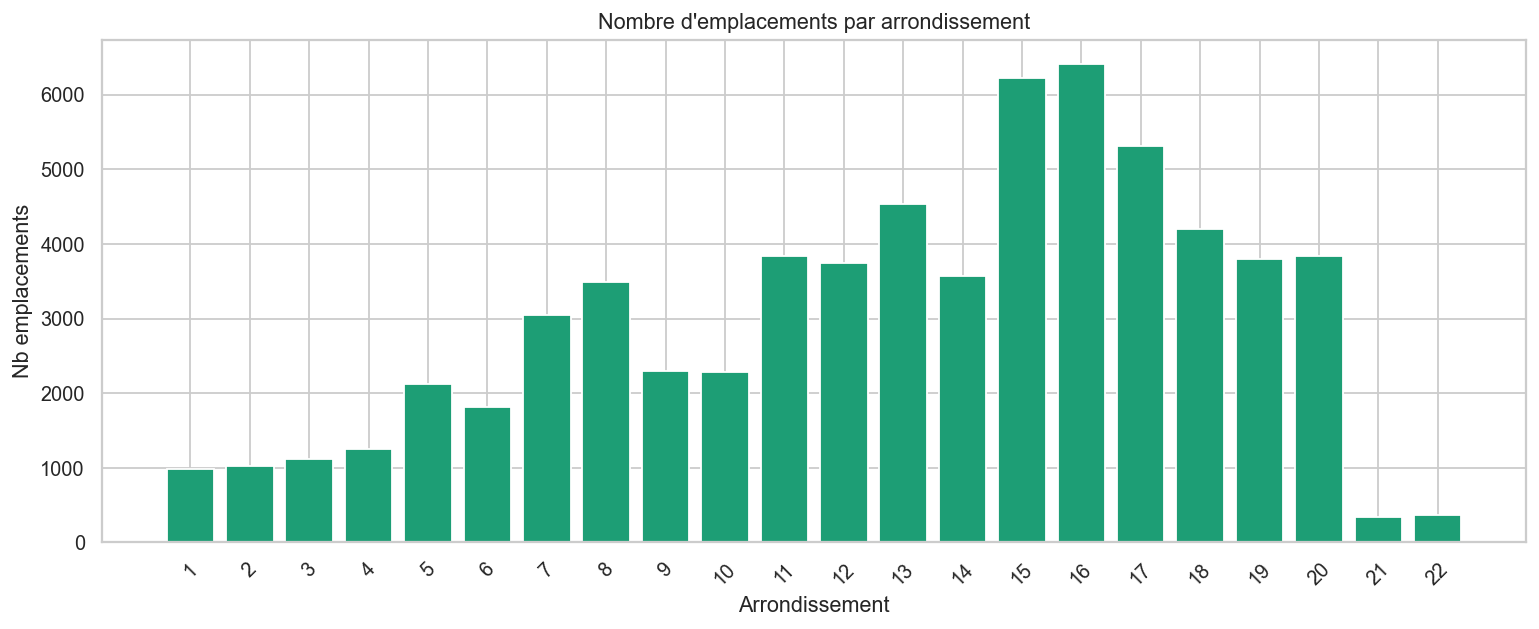

,nb_emplacements
Arrondissement,
1,980
2,1024
3,1118
4,1259
5,2128
6,1811
7,3048
8,3493
9,2291


In [9]:
arr_col = col_map['arrondissement']

if arr_col:
    print(f'Complétude : {df[arr_col].notna().sum()}/{len(df)} ({df[arr_col].notna().mean()*100:.1f}%)')
    print(f'Valeurs uniques : {sorted(df[arr_col].dropna().unique())}')

    arr_counts = df[arr_col].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.bar(arr_counts.index.astype(str), arr_counts.values, color='#1D9E75')
    ax.set_title('Nombre d\'emplacements par arrondissement')
    ax.set_xlabel('Arrondissement')
    ax.set_ylabel('Nb emplacements')
    ax.tick_params(axis='x', rotation=45)
    plt.tight_layout()
    plt.show()

    display(arr_counts.rename('nb_emplacements').to_frame())
else:
    print('❌ Colonne arrondissement non trouvée')

## 8. Analyse coordonnées GPS

Colonne géo trouvée : geo_point_2d
Exemple : 48.83607364266024, 2.3471517468142933
Complétude : 100.0%

Total coordonnées valides : 65,632
Dans Paris intra-muros    : 65,632 (100.0%)


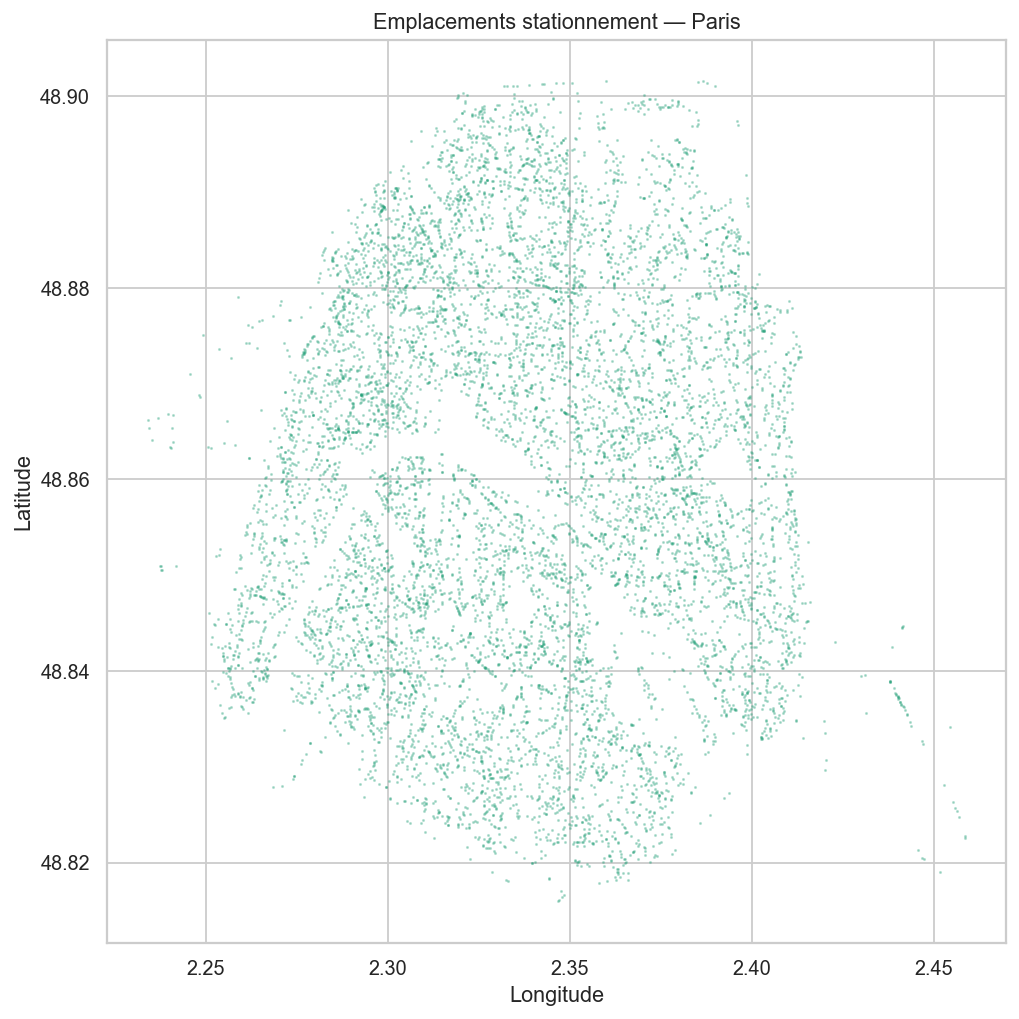

In [10]:
geo_col = col_map['geo_point']

if geo_col:
    print(f'Colonne géo trouvée : {geo_col}')
    print(f'Exemple : {df[geo_col].dropna().iloc[0]}')
    print(f'Complétude : {df[geo_col].notna().mean()*100:.1f}%')

    # Parser selon le format détecté
    sample = str(df[geo_col].dropna().iloc[0])
    if ',' in sample:
        coords = df[geo_col].dropna().str.split(',', expand=True)
        df['lat'] = pd.to_numeric(coords[0], errors='coerce')
        df['lon'] = pd.to_numeric(coords[1], errors='coerce')
    else:
        print('Format non standard — parsing manuel nécessaire')

    if 'lat' in df.columns and 'lon' in df.columns:
        geo = df[['lat','lon']].dropna()
        paris = geo[(geo['lat'].between(48.815, 48.902)) & (geo['lon'].between(2.225, 2.470))]
        print(f'\nTotal coordonnées valides : {len(geo):,}')
        print(f'Dans Paris intra-muros    : {len(paris):,} ({len(paris)/len(geo)*100:.1f}%)')

        sample_geo = paris.sample(min(10000, len(paris)), random_state=42)
        fig, ax = plt.subplots(figsize=(8, 8))
        ax.scatter(sample_geo['lon'], sample_geo['lat'], s=0.5, alpha=0.3, color='#1D9E75')
        ax.set_title('Emplacements stationnement — Paris')
        ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
        plt.tight_layout()
        plt.show()
else:
    print('❌ Colonne géo non trouvée')

## 9. Cardinalité colonnes catégorielles

In [11]:
cat_cols = df.select_dtypes(include='object').columns
cardinality = pd.DataFrame({
    'colonne'    : cat_cols,
    'unique'     : [df[c].nunique() for c in cat_cols],
    'exemple'    : [str(df[c].dropna().iloc[0])[:60] if not df[c].dropna().empty else 'N/A' for c in cat_cols],
    '% manquant' : [round(df[c].isnull().mean() * 100, 1) for c in cat_cols],
}).sort_values('unique', ascending=False)

display(cardinality)

,colonne,unique,exemple,% manquant
26,geo_shape,65632,"{""coordinates"": [2.3471517468142933, 48.836073...",0.0
27,geo_point_2d,65632,"48.83607364266024, 2.3471517468142933",0.0
20,Ancien identifiant,42799,863301D200509052802,34.8
21,Code voie Ville de Paris,3800,8858,0.0
6,Nom voie,3595,SAINT-HIPPOLYTE,0.0
7,Complément numéro voie,2945,BIS,90.3
24,Dernière modification,1306,2020-07-24,0.0
25,Date du relevé,1273,2020-07-09,0.0
3,Zones Résidentielles,162,13H,0.0
5,Type voie,107,RUE,0.0


## 10. Résumé + plan Silver

In [12]:
print('=' * 55)
print('RÉSUMÉ EDA — stationnement-voie-publique-emplacements.csv')
print('=' * 55)
print(f'  Lignes              : {len(df):,}')
print(f'  Colonnes            : {len(df.columns)}')
print(f'  Doublons            : {df.duplicated().sum()}')
missing_count = (df.isnull().sum() > 0).sum()
print(f'  Cols avec NaN       : {missing_count}')
if 'lat' in df.columns:
    print(f'  Lat range           : {df["lat"].min():.4f} → {df["lat"].max():.4f}')
    print(f'  Lon range           : {df["lon"].min():.4f} → {df["lon"].max():.4f}')
print('=' * 55)
print()
print('ACTIONS SILVER REQUISES :')
print('  → Parser geo_point → lat / lon')
print('  → Jointure spatiale → arrondissement (geopandas)')
print('  → Agréger : nb emplacements par type par arrondissement')
print('  → Calculer score stationnement par arrondissement')
print('  → Export Parquet')

RÉSUMÉ EDA — stationnement-voie-publique-emplacements.csv
  Lignes              : 65,632
  Colonnes            : 45
  Doublons            : 0
  Cols avec NaN       : 19
  Lat range           : 48.8159 → 48.9018
  Lon range           : 2.2275 → 2.4621

ACTIONS SILVER REQUISES :
  → Parser geo_point → lat / lon
  → Jointure spatiale → arrondissement (geopandas)
  → Agréger : nb emplacements par type par arrondissement
  → Calculer score stationnement par arrondissement
  → Export Parquet
